In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [56]:
# Read the dataset
Weather = pd.read_csv('../Datasets/Forecasting_Data.csv')
Weather.head()

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Source,Date,AQI_Category
0,2025-01-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,17.70,37.25,9.68,77.40,111.46,3.83,2025-01-01 12:00:00,OpenWeather,2025-01-01,Moderate
1,2025-01-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,19.87,33.26,28.91,39.20,56.06,14.72,2025-01-02 12:00:00,OpenWeather,2025-01-02,Satisfactory
2,2025-01-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,7.44,20.31,15.33,96.25,115.50,3.13,2025-01-03 12:00:00,OpenWeather,2025-01-03,Moderate
3,2025-01-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,32.39,19.23,15.71,37.80,54.05,8.77,2025-01-04 12:00:00,OpenWeather,2025-01-04,Satisfactory
4,2025-01-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,44.30,25.05,4.77,62.22,89.60,6.80,2025-01-05 12:00:00,OpenWeather,2025-01-05,Moderate


In [57]:
Weather_Forecast = Weather.copy()
Weather_Forecast

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Source,Date,AQI_Category
0,2025-01-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,17.70,37.25,9.68,77.40,111.46,3.83,2025-01-01 12:00:00,OpenWeather,2025-01-01,Moderate
1,2025-01-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,19.87,33.26,28.91,39.20,56.06,14.72,2025-01-02 12:00:00,OpenWeather,2025-01-02,Satisfactory
2,2025-01-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,7.44,20.31,15.33,96.25,115.50,3.13,2025-01-03 12:00:00,OpenWeather,2025-01-03,Moderate
3,2025-01-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,32.39,19.23,15.71,37.80,54.05,8.77,2025-01-04 12:00:00,OpenWeather,2025-01-04,Satisfactory
4,2025-01-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,44.30,25.05,4.77,62.22,89.60,6.80,2025-01-05 12:00:00,OpenWeather,2025-01-05,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11195,2026-07-10 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Clouds,...,29.74,75.99,24.21,26.23,34.10,1.82,2026-07-10 12:00:00,OpenWeather,2026-07-10,Satisfactory
11196,2026-07-11 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Clouds,...,13.81,55.84,24.48,21.42,32.99,3.53,2026-07-11 12:00:00,OpenWeather,2026-07-11,Satisfactory
11197,2026-07-12 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,44.53,47.29,28.07,27.47,39.83,2.44,2026-07-12 12:00:00,OpenWeather,2026-07-12,Satisfactory
11198,2026-07-13 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,23.33,78.19,8.87,18.90,26.27,6.63,2026-07-13 12:00:00,OpenWeather,2026-07-13,Good


In [58]:
Weather_Forecast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UpdatedAt           11200 non-null  object 
 1   Country             11200 non-null  object 
 2   CountryCode         11200 non-null  object 
 3   State               11200 non-null  object 
 4   StateCode           11200 non-null  object 
 5   City                11200 non-null  object 
 6   CityID              11200 non-null  int64  
 7   Latitude            11200 non-null  float64
 8   Longitude           11200 non-null  float64
 9   WeatherCondition    11200 non-null  object 
 10  WeatherDescription  11200 non-null  object 
 11  WeatherCode         11200 non-null  int64  
 12  Temperature         11200 non-null  float64
 13  FeelsLike           11200 non-null  float64
 14  TempMin             11200 non-null  int64  
 15  TempMax             11200 non-null  int64  
 16  Pres

In [59]:
print("Columns:- ", Weather_Forecast.columns.tolist())
print("\nShape:- ", Weather_Forecast.shape)
print("\nUnique Cities:- ", Weather_Forecast["City"].nunique())
print("\nCity Counts:- ", Weather_Forecast["City"].value_counts())
print("\nMin Date:- ", Weather_Forecast["Date"].min())
print("\nMax Date:- ", Weather_Forecast["Date"].max())
print("\nNull Values:- ", Weather_Forecast.isnull().sum())

Columns:-  ['UpdatedAt', 'Country', 'CountryCode', 'State', 'StateCode', 'City', 'CityID', 'Latitude', 'Longitude', 'WeatherCondition', 'WeatherDescription', 'WeatherCode', 'Temperature', 'FeelsLike', 'TempMin', 'TempMax', 'Pressure', 'Humidity', 'SeaLevel', 'GroundLevel', 'WindSpeed', 'WindDirection', 'WindGust', 'CloudCoverage', 'Visibility', 'AQI', 'CO', 'NO', 'NO2', 'O3', 'SO2', 'PM25', 'PM10', 'NH3', 'CreatedAt', 'Source', 'Date', 'AQI_Category']

Shape:-  (11200, 38)

Unique Cities:-  20

City Counts:-  City
Ahmedabad        560
Bengaluru        560
Bhopal           560
Chennai          560
Delhi            560
Goa              560
Hyderabad        560
Jaipur           560
Kanpur           560
Kochi            560
Kolkata          560
Lucknow          560
Mumbai           560
Mysuru           560
Nagpur           560
Patna            560
Pune             560
Surat            560
Varanasi         560
Visakhapatnam    560
Name: count, dtype: int64

Min Date:-  2025-01-01

Max Date:

## 🌦️ PHASE 2 — Temperature Forecasting Model (Single City)

### Step 3.1 — Create Ahmedabad Dataset

In [60]:
city = "Ahmedabad"
city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
print("\nShape:- ", city_df.shape)
city_df.head()


Shape:-  (560, 38)


,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Source,Date,AQI_Category
0,2025-01-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,17.70,37.25,9.68,77.40,111.46,3.83,2025-01-01 12:00:00,OpenWeather,2025-01-01,Moderate
1,2025-01-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,19.87,33.26,28.91,39.20,56.06,14.72,2025-01-02 12:00:00,OpenWeather,2025-01-02,Satisfactory
2,2025-01-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,7.44,20.31,15.33,96.25,115.50,3.13,2025-01-03 12:00:00,OpenWeather,2025-01-03,Moderate
3,2025-01-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,32.39,19.23,15.71,37.80,54.05,8.77,2025-01-04 12:00:00,OpenWeather,2025-01-04,Satisfactory
4,2025-01-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,44.30,25.05,4.77,62.22,89.60,6.80,2025-01-05 12:00:00,OpenWeather,2025-01-05,Moderate


### Step 3.2 — Prepare Data for Prophet

In [61]:
prophet_df = city_df[["Date", "Temperature"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2025-01-01,13.53
1,2025-01-02,13.52
2,2025-01-03,14.82
3,2025-01-04,22.58
4,2025-01-05,22.86


### Step 3.3 — Verify Dataset

In [62]:
prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 560 entries, 0 to 559
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      560 non-null    object 
 1   y       560 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.1+ KB


### Step 3.4 — Plot Historical Temperature

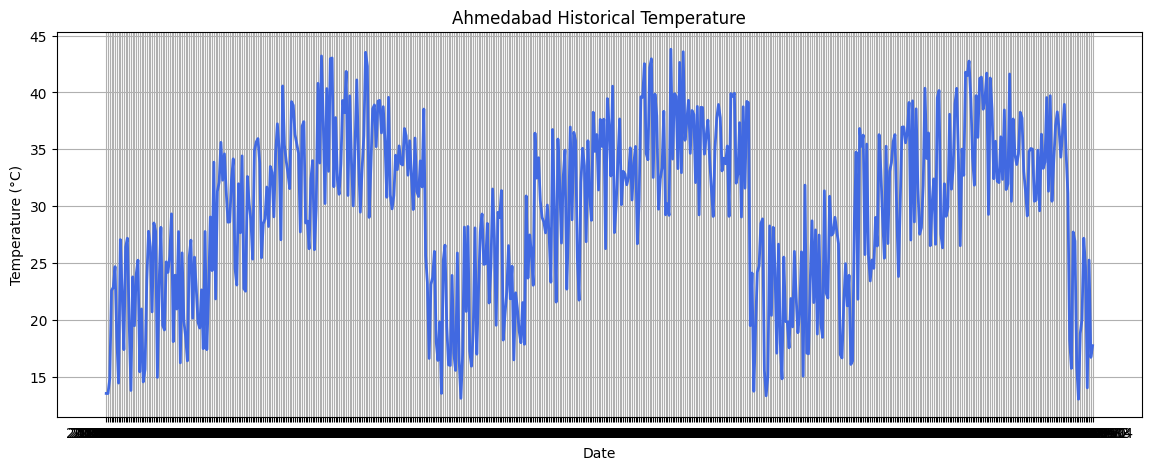

In [63]:
plt.figure(figsize=(14,5))
plt.plot(prophet_df["ds"], prophet_df["y"], color="royalblue", linewidth=2)

plt.title("Ahmedabad Historical Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Step 3.5 — Create Prophet Model

In [64]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

### Step 3.6 — Train Model

In [65]:
model.fit(prophet_df)

15:19:47 - cmdstanpy - INFO - Chain [1] start processing
15:19:47 - cmdstanpy - INFO - Chain [1] done processing


### Step 3.7 — Create Future Dates

In [66]:
# Here, "model.make_future_dataframe" is used to create a dataframe that extends into the future for the specified number of periods 
# (60 days in this case) with a daily frequency. This future dataframe will be used to make predictions for the next 60 days based on the 
# historical data that was used to fit the model.
future = model.make_future_dataframe(periods=60, freq="D")
future.tail()

,ds
615,2026-09-08
616,2026-09-09
617,2026-09-10
618,2026-09-11
619,2026-09-12


### Step 3.8 — Forecast

In [67]:
# Here, model.predict is used to generate forecasts for the future dates specified in the "future" dataframe. 
# The resulting "forecast" dataframe will contain the predicted values along with additional information such as confidence intervals and trend components.
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01,29.433778,20.230380,31.926607,29.433778,29.433778,-3.379437,-3.379437,-3.379437,0.078647,0.078647,0.078647,-3.458084,-3.458084,-3.458084,0.0,0.0,0.0,26.054341
1,2025-01-02,29.435457,19.009826,30.461459,29.435457,29.435457,-4.588221,-4.588221,-4.588221,-0.292116,-0.292116,-0.292116,-4.296104,-4.296104,-4.296104,0.0,0.0,0.0,24.847237
2,2025-01-03,29.437136,18.426497,30.358269,29.437136,29.437136,-5.124782,-5.124782,-5.124782,-0.016328,-0.016328,-0.016328,-5.108455,-5.108455,-5.108455,0.0,0.0,0.0,24.312354
3,2025-01-04,29.438815,17.274423,29.661487,29.438815,29.438815,-6.095986,-6.095986,-6.095986,-0.211423,-0.211423,-0.211423,-5.884563,-5.884563,-5.884563,0.0,0.0,0.0,23.342829
4,2025-01-05,29.440494,17.358775,29.225529,29.440494,29.440494,-6.341117,-6.341117,-6.341117,0.273368,0.273368,0.273368,-6.614485,-6.614485,-6.614485,0.0,0.0,0.0,23.099378


### Step 3.9 — Display Important Columns

In [68]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
610,2026-09-03,27.801610,21.786509,33.446938
611,2026-09-04,28.508774,22.841651,34.441057
612,2026-09-05,28.722724,22.515275,34.364391
613,2026-09-06,29.589210,24.054230,35.963840
614,2026-09-07,30.063949,24.045965,35.937607
615,2026-09-08,29.752252,24.279299,35.472954
616,2026-09-09,30.340717,23.984539,36.205569
617,2026-09-10,30.213033,24.272743,36.213886
618,2026-09-11,30.695522,24.542497,36.617982
619,2026-09-12,30.672224,24.589939,36.358767


### Step 3.10 — Plot Forecast

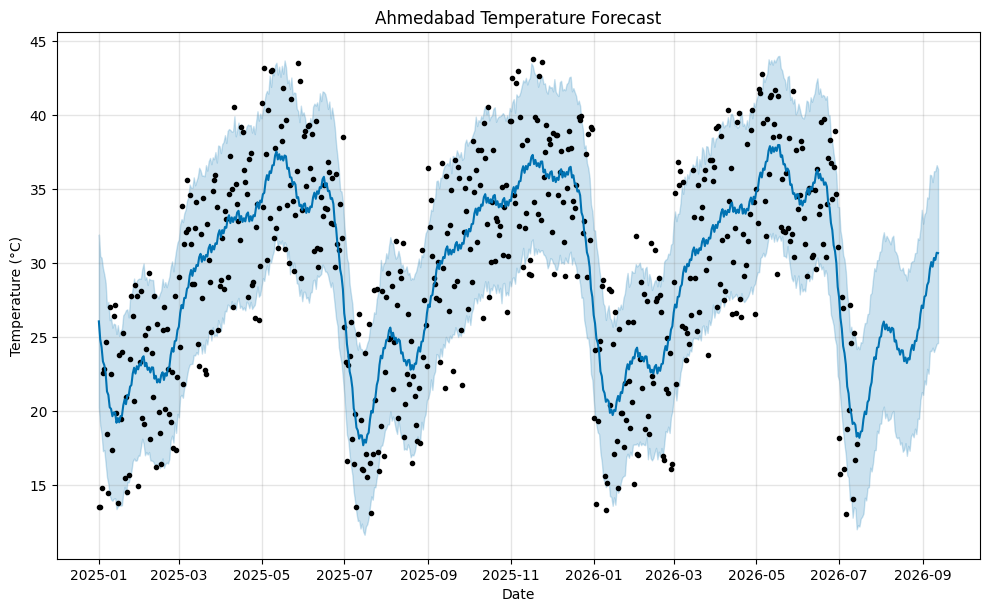

In [69]:
fig = model.plot(forecast)

plt.title("Ahmedabad Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Step 3.11 — Plot Components

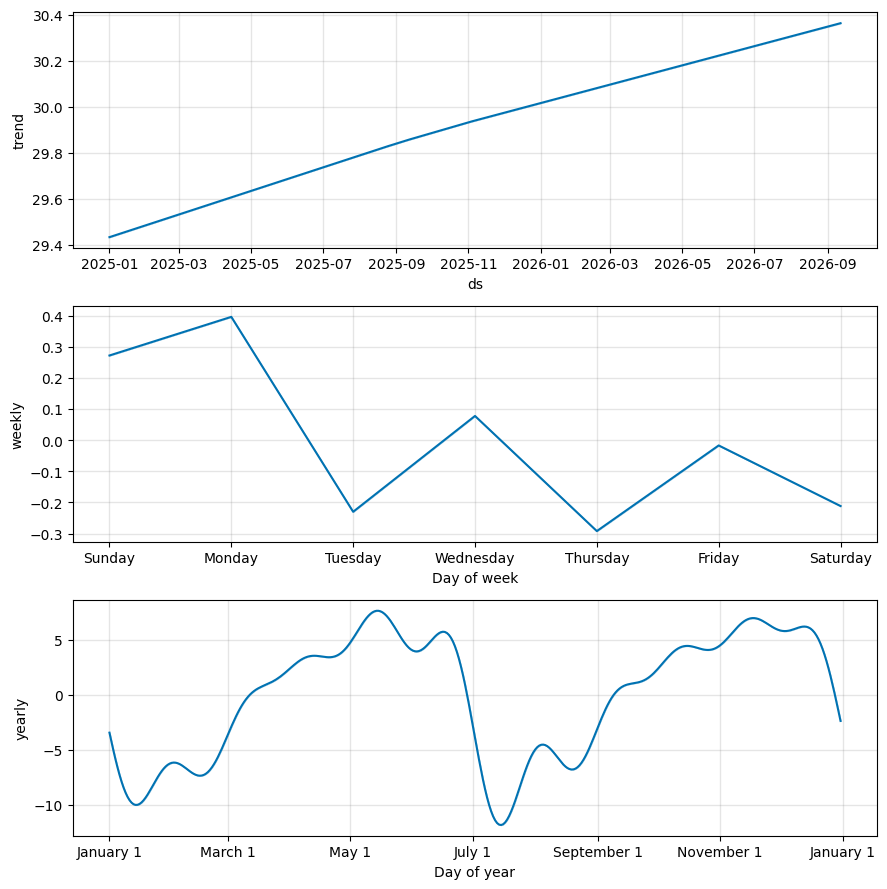

In [70]:
# Here, model.plot_components is used to visualize the individual components of the forecast, such as trend, yearly seasonality, and 
# weekly seasonality.
model.plot_components(forecast)
plt.show()

### Step 3.12 — Predict One Date

In [71]:
target_date = "2026-07-30"

prediction = forecast.loc[
    forecast["ds"] == target_date,
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

prediction

,ds,yhat,yhat_lower,yhat_upper
575,2026-07-30,24.31525,18.487807,30.203909


### Step 3.13 — Save Model

In [72]:
os.makedirs("../sample_weather_models", exist_ok=True)
joblib.dump(model, "../sample_weather_models/Ahmedabad_temperature.pkl")

['../sample_weather_models/Ahmedabad_temperature.pkl']

In [73]:
print(os.listdir("../sample_weather_models"))

['Ahmedabad_temperature.pkl']


In [74]:
# Delete the existing model folder sample_weather_models
import shutil

if os.path.exists("../sample_weather_models"):
    shutil.rmtree("../sample_weather_models")
    print("Deleted existing folder: sample_weather_models")

Deleted existing folder: sample_weather_models


## 🌦️ PHASE 4 — Train Temperature Models for All 20 Cities

### Step 4.1 — Create Models Folder

In [111]:
os.makedirs("../temp_weather_models", exist_ok=True)

### Step 4.2 — Get All Cities

In [112]:
cities = sorted(Weather_Forecast["City"].unique())

print(cities)
print(f"Total Cities: {len(cities)}")

['Ahmedabad', 'Bengaluru', 'Bhopal', 'Chennai', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Kanpur', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Mysuru', 'Nagpur', 'Patna', 'Pune', 'Surat', 'Varanasi', 'Visakhapatnam']
Total Cities: 20


### Step 4.3 — Train All Temperature Models

In [113]:
from prophet import Prophet
import joblib

for city in cities:
    print(f"Training Model for {city}...")
    city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
    prophet_df = city_df[["Date", "Temperature"]].copy()
    prophet_df.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(prophet_df)
    model_path = f"../temp_weather_models/{city}_temperature.pkl"
    joblib.dump(model, model_path)
    print(f"Saved -> {model_path}")

print("\n✅ All Temperature Models Trained Successfully!")

Training Model for Ahmedabad...


18:44:55 - cmdstanpy - INFO - Chain [1] start processing
18:44:56 - cmdstanpy - INFO - Chain [1] done processing
18:44:56 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../temp_weather_models/Ahmedabad_temperature.pkl
Training Model for Bengaluru...


18:44:56 - cmdstanpy - INFO - Chain [1] done processing
18:44:56 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../temp_weather_models/Bengaluru_temperature.pkl
Training Model for Bhopal...


...

Saved -> ../temp_weather_models/Surat_temperature.pkl
Training Model for Varanasi...


18:45:03 - cmdstanpy - INFO - Chain [1] done processing
18:45:04 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../temp_weather_models/Varanasi_temperature.pkl
Training Model for Visakhapatnam...


18:45:04 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../temp_weather_models/Visakhapatnam_temperature.pkl

✅ All Temperature Models Trained Successfully!


### Step 4.4 — Verify

In [114]:
models = os.listdir("../weather_models")
print(models)
print(f"\nTotal Models: {len(models)}")

['Humidity', 'Pressure', 'Temperature', 'WindSpeed']

Total Models: 4


### Step 4.5 — Test One Model

In [122]:
model = joblib.load("../temp_weather_models/Goa_temperature.pkl")

today = pd.Timestamp.today().normalize()
target_date = pd.to_datetime("2026-07-30")
days = (target_date - today).days

 # Create future dataframe
future = model.make_future_dataframe(periods=days, freq="D")
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
570,2026-07-25,28.424014,23.610902,29.596094,28.423920,28.424101,-1.834637,-1.834637,-1.834637,-0.060917,-0.060917,-0.060917,-1.773720,-1.773720,-1.773720,0.0,0.0,0.0,26.589377
571,2026-07-26,28.424590,23.842690,29.770654,28.424462,28.424702,-1.597687,-1.597687,-1.597687,0.014577,0.014577,0.014577,-1.612265,-1.612265,-1.612265,0.0,0.0,0.0,26.826903
572,2026-07-27,28.425166,23.835399,29.858203,28.425017,28.425307,-1.566870,-1.566870,-1.566870,-0.111593,-0.111593,-0.111593,-1.455277,-1.455277,-1.455277,0.0,0.0,0.0,26.858296
573,2026-07-28,28.425742,23.911423,29.875868,28.425557,28.425908,-1.572295,-1.572295,-1.572295,-0.266476,-0.266476,-0.266476,-1.305819,-1.305819,-1.305819,0.0,0.0,0.0,26.853447
574,2026-07-29,28.426318,24.826005,30.597140,28.426092,28.426511,-0.629161,-0.629161,-0.629161,0.537586,0.537586,0.537586,-1.166746,-1.166746,-1.166746,0.0,0.0,0.0,27.797158


### Step 4.6 — Predict Any Date & Visualize

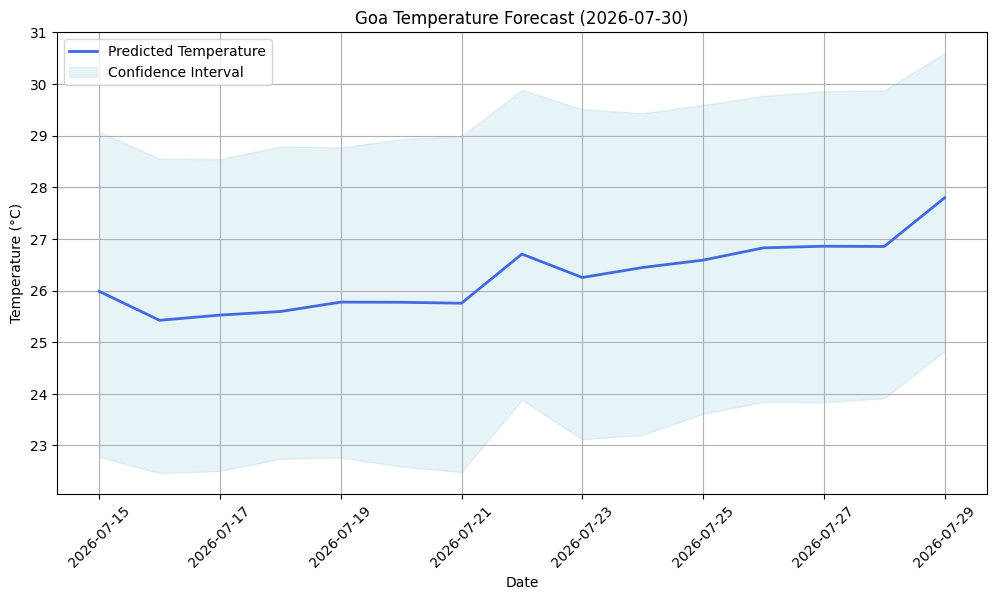

In [123]:
result = forecast[(forecast["ds"] >= today) & (forecast["ds"] <= target_date)][["ds", "yhat", "yhat_lower", "yhat_upper"]]

    # Rename Columns
result.columns = ["Date", "Predicted Temperature (°C)", "Lower Bound", "Upper Bound"]

plt.figure(figsize=(12,6))
plt.plot(result["Date"], result["Predicted Temperature (°C)"], color="royalblue", linewidth=2, label="Predicted Temperature")
plt.fill_between(result["Date"], result["Lower Bound"], result["Upper Bound"], color="lightblue", alpha=0.3, label="Confidence Interval")
plt.title("Goa Temperature Forecast (2026-07-30)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


In [96]:
# Delete temp_weather_models folder if it exists
from pathlib import Path

folder = Path("../temp_weather_models")

try:
    folder.rmdir()
    print("Folder deleted successfully.")
except FileNotFoundError:
    print("The folder does not exist.")
except OSError:
    print("The folder is not empty.")


The folder is not empty.


## 🌦️ PHASE 5 — Forecast All Weather Parameters

### Step 5.1 — Create Folder Structure

In [97]:
Weather_Forecast

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Source,Date,AQI_Category
0,2025-01-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,17.70,37.25,9.68,77.40,111.46,3.83,2025-01-01 12:00:00,OpenWeather,2025-01-01,Moderate
1,2025-01-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,19.87,33.26,28.91,39.20,56.06,14.72,2025-01-02 12:00:00,OpenWeather,2025-01-02,Satisfactory
2,2025-01-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,7.44,20.31,15.33,96.25,115.50,3.13,2025-01-03 12:00:00,OpenWeather,2025-01-03,Moderate
3,2025-01-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,32.39,19.23,15.71,37.80,54.05,8.77,2025-01-04 12:00:00,OpenWeather,2025-01-04,Satisfactory
4,2025-01-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,44.30,25.05,4.77,62.22,89.60,6.80,2025-01-05 12:00:00,OpenWeather,2025-01-05,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11195,2026-07-10 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Clouds,...,29.74,75.99,24.21,26.23,34.10,1.82,2026-07-10 12:00:00,OpenWeather,2026-07-10,Satisfactory
11196,2026-07-11 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Clouds,...,13.81,55.84,24.48,21.42,32.99,3.53,2026-07-11 12:00:00,OpenWeather,2026-07-11,Satisfactory
11197,2026-07-12 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,44.53,47.29,28.07,27.47,39.83,2.44,2026-07-12 12:00:00,OpenWeather,2026-07-12,Satisfactory
11198,2026-07-13 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,23.33,78.19,8.87,18.90,26.27,6.63,2026-07-13 12:00:00,OpenWeather,2026-07-13,Good


In [98]:
parameters = ["Temperature", "Humidity", "Pressure", "WindSpeed"]

for parameter in parameters:
    os.makedirs(f"../weather_models/{parameter}", exist_ok=True)

print("Folders Created Successfully!")

Folders Created Successfully!


### Step 5.2 — Create a Reusable Function

In [99]:
def train_weather_model(city, parameter):

    city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
    prophet_df = city_df[["Date", parameter]].copy()

    prophet_df.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(prophet_df)
    path = f"../weather_models/{parameter}/{city}.pkl"
    joblib.dump(model, path)
    return path

### Step 5.3 — Train Every Model

In [100]:
cities = sorted(Weather_Forecast["City"].unique())
parameters = ["Temperature", "Humidity", "Pressure", "WindSpeed"]

for parameter in parameters:
    print(f"\nTraining {parameter} Models...\n")

    for city in cities:
        path = train_weather_model(city, parameter)
        print(f"Saved -> {path}")

print("\nAll Weather Models Created Successfully!")


Training Temperature Models...



15:32:45 - cmdstanpy - INFO - Chain [1] start processing
15:32:45 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../weather_models/Temperature/Ahmedabad.pkl


15:32:47 - cmdstanpy - INFO - Chain [1] start processing
15:32:47 - cmdstanpy - INFO - Chain [1] done processing
15:32:47 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../weather_models/Temperature/Bengaluru.pkl


...

Saved -> ../weather_models/WindSpeed/Surat.pkl


15:33:30 - cmdstanpy - INFO - Chain [1] start processing
15:33:30 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../weather_models/WindSpeed/Varanasi.pkl


15:33:31 - cmdstanpy - INFO - Chain [1] start processing
15:33:31 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../weather_models/WindSpeed/Visakhapatnam.pkl

All Weather Models Created Successfully!


### Step 5.4 — Verify

In [101]:
for parameter in parameters:
    models = os.listdir(f"../weather_models/{parameter}")
    print(parameter)
    print(len(models))
    print("-"*40)

Temperature
20
----------------------------------------
Humidity
20
----------------------------------------
Pressure
20
----------------------------------------
WindSpeed
20
----------------------------------------


### Step 5.5 — Test One Model

In [102]:
# Temperature
model = joblib.load("../weather_models/Temperature/Kolkata.pkl")
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
585,2026-08-09,28.048590,18.662624,27.720576,28.048590,28.048590,-4.728522,-4.728522,-4.728522,0.247819,0.247819,0.247819,-4.976341,-4.976341,-4.976341,0.0,0.0,0.0,23.320068
586,2026-08-10,28.049438,18.231698,27.267921,28.049438,28.049438,-5.481747,-5.481747,-5.481747,-0.419001,-0.419001,-0.419001,-5.062746,-5.062746,-5.062746,0.0,0.0,0.0,22.567691
587,2026-08-11,28.050285,18.494520,27.343110,28.050285,28.050286,-4.857563,-4.857563,-4.857563,0.288193,0.288193,0.288193,-5.145756,-5.145756,-5.145756,0.0,0.0,0.0,23.192722
588,2026-08-12,28.051133,17.732428,27.052014,28.051133,28.051133,-5.605129,-5.605129,-5.605129,-0.387091,-0.387091,-0.387091,-5.218038,-5.218038,-5.218038,0.0,0.0,0.0,22.446004
589,2026-08-13,28.051981,18.453835,27.686997,28.051981,28.051981,-4.736943,-4.736943,-4.736943,0.535636,0.535636,0.535636,-5.272580,-5.272580,-5.272580,0.0,0.0,0.0,23.315038


In [103]:
# Humidity
model = joblib.load("../weather_models/Humidity/Kolkata.pkl")
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
585,2026-08-09,76.728515,58.224387,77.592168,76.728218,76.728818,-8.544272,-8.544272,-8.544272,-1.263762,-1.263762,-1.263762,-7.280509,-7.280509,-7.280509,0.0,0.0,0.0,68.184244
586,2026-08-10,76.732078,59.881742,79.190973,76.731759,76.732396,-7.205443,-7.205443,-7.205443,0.281756,0.281756,0.281756,-7.487198,-7.487198,-7.487198,0.0,0.0,0.0,69.526636
587,2026-08-11,76.735641,61.032896,80.442393,76.735297,76.735980,-6.387446,-6.387446,-6.387446,1.287454,1.287454,1.287454,-7.674901,-7.674901,-7.674901,0.0,0.0,0.0,70.348195
588,2026-08-12,76.739204,60.396016,79.421575,76.738832,76.739567,-7.204333,-7.204333,-7.204333,0.631750,0.631750,0.631750,-7.836083,-7.836083,-7.836083,0.0,0.0,0.0,69.534871
589,2026-08-13,76.742767,59.366777,79.062680,76.742371,76.743162,-7.578048,-7.578048,-7.578048,0.386058,0.386058,0.386058,-7.964107,-7.964107,-7.964107,0.0,0.0,0.0,69.164719


### Step 5.6 — Create Forecast Function

In [104]:
def forecast_weather(city, parameter, target_date):
    model = joblib.load(f"../weather_models/{parameter}/{city}.pkl")
    future = model.make_future_dataframe(periods=365)
    
    forecast = model.predict(future)
    prediction = forecast[forecast["ds"] == pd.to_datetime(target_date)]

    return prediction["yhat"].iloc[0]

In [105]:
# Temperature
forecast_weather(
    "Delhi",
    "Temperature",
    "2026-08-10"
)

np.float64(20.4237806042486)

In [106]:
# Humidity
forecast_weather(
    "Delhi",
    "Humidity",
    "2026-08-10"
)

np.float64(54.87528138185992)

### Step 5.7 — Forecast All Parameters Together

In [107]:
city = "Delhi"
date = "2026-08-10"
temperature = forecast_weather(city, "Temperature", date)
humidity = forecast_weather(city, "Humidity", date)
pressure = forecast_weather(city, "Pressure", date)
wind = forecast_weather(city, "WindSpeed", date)

print(f"""
Temperature : {temperature:.1f}°C
Humidity : {humidity:.1f}%
Pressure : {pressure:.0f} hPa
Wind Speed : {wind:.1f} km/h""")


Temperature : 20.4°C
Humidity : 54.9%
Pressure : 1005 hPa
Wind Speed : 4.1 km/h
